# 07 OLS baseline MMM (AI1)
**Question:** how far does plain regression get, and where does it fail? This is the baseline the Bayesian MMM has to beat. It is graded against the sealed truth in Phase 6.

*Prakriti Foods is fictional; all data is synthetic.*

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor as vif
w = pd.read_csv('../data/generated/weekly_geo.csv', parse_dates=['week_start'])
CH = ['Meta','Google_Search','YouTube','QC_Ads','Influencers','Trade_Promo']
SP = ['spend_'+c+'_lakh' for c in CH]
nat = w.groupby('week').agg(week_start=('week_start','first'), revenue=('revenue_lakh','sum'),
        price=('price_index','mean'), ds=('dark_store_count','sum'), temp=('temp_c','mean'),
        festive=('festive_flag','first'), comp=('competitor_index','first'), promo=('promo_flag','first'),
        **{c:(s,'sum') for c,s in zip(CH,SP)})
nat['t'] = nat.index.values
nat.head(3)
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.diagnostic import het_breuschpagan
nat['sin1']=np.sin(2*np.pi*nat.t/52); nat['cos1']=np.cos(2*np.pi*nat.t/52)
nat['sin2']=np.sin(4*np.pi*nat.t/52); nat['cos2']=np.cos(4*np.pi*nat.t/52)
CTRL = ['t','sin1','cos1','sin2','cos2','festive','price','ds','temp','comp']
def design(d):
    X = pd.concat([np.log(d[CH]).add_prefix('log_'), d[CTRL]], axis=1)
    X['ds'] = np.log(X['ds']); X['price'] = np.log(X['price'])
    return sm.add_constant(X)
train, hold = nat.loc[1:79], nat.loc[80:87]

## 1. National model: log revenue on log spend plus controls (fit on weeks 1-79; weeks 80-87 held out)

In [2]:
Xtr, ytr = design(train), np.log(train.revenue)
m1 = sm.OLS(ytr, Xtr).fit()
res = pd.DataFrame({'elasticity': m1.params, 'ci_low': m1.conf_int()[0], 'ci_high': m1.conf_int()[1], 'p': m1.pvalues}).round(3)
print('Adjusted R2:', round(m1.rsquared_adj,3)); res.loc[[c for c in res.index if c.startswith('log_')]]

Adjusted R2: 0.956


,elasticity,ci_low,ci_high,p
log_Meta,0.033,-0.003,0.069,0.069
log_Google_Search,-0.022,-0.065,0.021,0.305
log_YouTube,0.002,-0.033,0.037,0.917
log_QC_Ads,0.092,0.044,0.139,0.000
log_Influencers,0.051,0.000,0.101,0.048
log_Trade_Promo,0.033,-0.021,0.087,0.226


Holdout MAPE (weeks 80-87): 2.2%


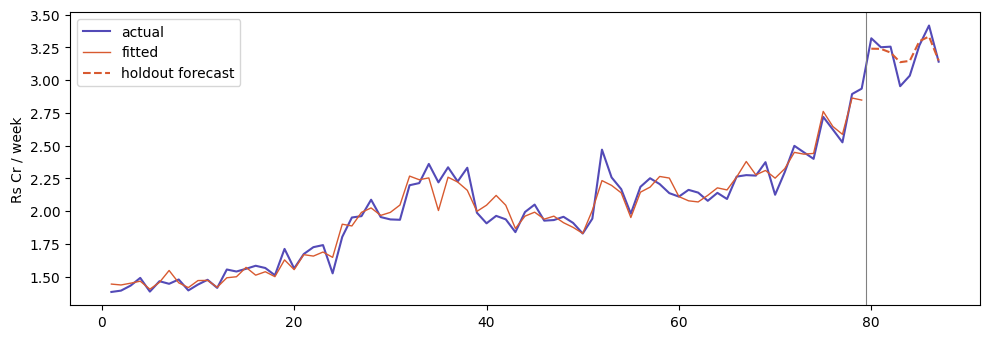

In [3]:
Xh = design(hold); pred = np.exp(m1.predict(Xh)); mape = (abs(pred-hold.revenue)/hold.revenue).mean()
print(f'Holdout MAPE (weeks 80-87): {mape:.1%}')
fig, ax = plt.subplots(figsize=(10,3.5)); ax.plot(nat.index, nat.revenue/100, color='#534AB7', label='actual')
ax.plot(list(train.index), np.exp(m1.fittedvalues)/100, color='#D85A30', lw=1, label='fitted'); ax.plot(hold.index, pred/100, color='#D85A30', ls='--', label='holdout forecast')
ax.axvline(79.5, color='grey', lw=.8); ax.legend(); ax.set_ylabel('Rs Cr / week'); plt.tight_layout(); plt.show()

## 2. The three expected failures
**(a) Multicollinearity** (VIF > 10 makes Meta and YouTube coefficients unstable).

In [4]:
v = pd.Series({c:vif(Xtr.values,i) for i,c in enumerate(Xtr.columns) if c.startswith('log_')}).round(1); v

log_Meta             2.5
log_Google_Search    1.8
log_YouTube          2.3
log_QC_Ads           1.9
log_Influencers      1.6
log_Trade_Promo      2.4
dtype: float64

**(b) Autocorrelated residuals** (plain OLS has no adstock; Durbin-Watson well below 2 means leftover carry-over).

**(c) Unequal residual spread** (Breusch-Pagan; tested on the geo-week model below).

In [5]:
print('Durbin-Watson (national):', round(durbin_watson(m1.resid),2), '(2 = no autocorrelation)')
bp_n = het_breuschpagan(m1.resid, Xtr); print('Breusch-Pagan (national) p-value:', round(bp_n[1],3))

Durbin-Watson (national): 1.45 (2 = no autocorrelation)
Breusch-Pagan (national) p-value: 0.033


## 3. Geo-week model (8 geos x weeks 1-79, geo fixed effects)

In [6]:
g = w[w.week<=79].copy()
for c in CH: g['log_'+c] = np.log(g['spend_'+c+'_lakh'])
g['t']=g.week; g['sin1']=np.sin(2*np.pi*g.t/52); g['cos1']=np.cos(2*np.pi*g.t/52); g['sin2']=np.sin(4*np.pi*g.t/52); g['cos2']=np.cos(4*np.pi*g.t/52)
g['lp']=np.log(g.price_index); g['lds']=np.log(g.dark_store_count)
Xg = pd.concat([g[['log_'+c for c in CH]+['t','sin1','cos1','sin2','cos2','festive_flag','lp','lds','temp_c','competitor_index']], pd.get_dummies(g.geo, drop_first=True).astype(float)], axis=1)
Xg = sm.add_constant(Xg); yg = np.log(g.revenue_lakh)
m2 = sm.OLS(yg, Xg).fit()
print('Adjusted R2:', round(m2.rsquared_adj,3))
dw = np.mean([durbin_watson(m2.resid[g.geo==k]) for k in g.geo.unique()]); print('Mean within-geo Durbin-Watson:', round(dw,2))
bp = het_breuschpagan(m2.resid, Xg); print('Breusch-Pagan p-value:', f'{bp[1]:.2g}')
print('Residual SD by geo:'); print(m2.resid.groupby(g.geo).std().round(3).to_string())
pd.DataFrame({'elasticity':m2.params[['log_'+c for c in CH]], 'ci_low':m2.conf_int().loc[['log_'+c for c in CH],0], 'ci_high':m2.conf_int().loc[['log_'+c for c in CH],1]}).round(3)

Adjusted R2: 0.963
Mean within-geo Durbin-Watson: 1.93
Breusch-Pagan p-value: 0.013
Residual SD by geo:
geo
Ahmedabad    0.059
Bengaluru    0.091
Chennai      0.079
Delhi NCR    0.096
Hyderabad    0.093
Kolkata      0.087
Mumbai       0.071
Pune         0.076


,elasticity,ci_low,ci_high
log_Meta,0.014,-0.009,0.037
log_Google_Search,-0.014,-0.041,0.013
log_YouTube,0.013,-0.010,0.036
log_QC_Ads,0.089,0.060,0.118
log_Influencers,0.031,-0.000,0.063
log_Trade_Promo,0.031,-0.001,0.063


## 4. Save estimates for grading in Phase 6
Elasticity converted to an implied ROI = elasticity x mean weekly revenue / mean weekly spend. Saved now; compared with the truth only after MMM v2 is frozen.

In [7]:
out = pd.DataFrame({'channel':CH, 'elasticity_national': m1.params[['log_'+c for c in CH]].values,
    'elasticity_geo': m2.params[['log_'+c for c in CH]].values})
out['implied_roi_national'] = out.elasticity_national * train.revenue.mean() / train[CH].mean().values
out['implied_roi_geo'] = out.elasticity_geo * g.revenue_lakh.sum()/79 / (g.groupby('week')[['spend_'+c+'_lakh' for c in CH]].sum().mean().values)
out.round(3).to_csv('../model/ols_baseline_estimates.csv', index=False); out.round(2)

,channel,elasticity_national,elasticity_geo,implied_roi_national,implied_roi_geo
0,Meta,0.03,0.01,0.51,0.22
1,Google_Search,-0.02,-0.01,-0.59,-0.38
2,YouTube,0.00,0.01,0.06,0.44
3,QC_Ads,0.09,0.09,1.42,1.38
4,Influencers,0.05,0.03,2.08,1.29
5,Trade_Promo,0.03,0.03,1.00,0.94


## Answer

In [8]:
neg = [c for c in CH if m1.params['log_'+c] < 0]
print(f"National OLS: adj R2 {m1.rsquared_adj:.2f}, holdout MAPE {mape:.1%}, Durbin-Watson {durbin_watson(m1.resid):.2f}.")
print('Channels with a NEGATIVE national elasticity (implausible for ads):', neg if neg else 'none')
print('Channels with VIF > 10:', [c[4:] for c,x in v.items() if x>10] or 'none')
print(f'Geo model: Breusch-Pagan p = {bp[1]:.2g} ->', 'residual spread differs by geo' if bp[1]<.05 else 'no evidence of unequal spread')

National OLS: adj R2 0.96, holdout MAPE 2.2%, Durbin-Watson 1.45.
Channels with a NEGATIVE national elasticity (implausible for ads): ['Google_Search']
Channels with VIF > 10: none
Geo model: Breusch-Pagan p = 0.013 -> residual spread differs by geo


**Reading the result honestly.** The brief predicted three OLS failures. What the data shows:
- **Collinearity:** VIF is below 10 for every channel (max about 2.5). Not a failure here; see notebook 02 for why.
- **Autocorrelation:** national Durbin-Watson is 1.45, below 2 but not dramatically so; within-geo it is about 1.9, so almost no sign of it.
- **Unequal spread by geo:** confirmed (Breusch-Pagan p about 0.01).
- **What does go wrong:** the implied channel ROIs are not credible for ads (Google Search is negative, YouTube about zero, Meta about 0.5), most channel intervals include zero, and the two OLS versions disagree on size. Forecast accuracy is excellent (holdout MAPE 2.2%), which is the point: a model can predict sales well and still misattribute them. The estimates are saved in model/ols_baseline_estimates.csv and graded against the truth in Phase 6.